In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import joblib
import os
from tensorflow.keras.models import load_model

I0000 00:00:1780234295.174796   45648 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1780234295.255328   45648 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780234297.522811   45648 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
print("1. Memuat Dataset dan Model...")

# Menangani path agar aman dijalankan di Jupyter Notebook maupun Terminal
try:
    # Jika dijalankan via terminal (.py)
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # Jika dijalankan langsung di cell Jupyter Notebook (.ipynb)
    BASE_DIR = os.getcwd()

path_data = os.path.join(BASE_DIR, 'data_testing_baru.csv')
path_scaler = os.path.join(BASE_DIR, 'models', 'scaler.pkl')
path_xgb = os.path.join(BASE_DIR, 'models', 'xgb_model3.pkl')
path_gru = os.path.join(BASE_DIR, 'models', 'gru_model3.keras')

1. Memuat Dataset dan Model...


In [3]:
# 1. Load Data Testing Asli
df = pd.read_csv(path_data)
fitur_x = [
    'ph', 'Solids', 'Turbidity', 'Temperature',
    'Turbidity_MA_3', 'Solids_MA_3', 'ph_MA_3',
    'Turbidity_Diff', 'Solids_Diff', 'ph_Diff',
    'Turbidity_Std_3', 'Solids_Std_3'
]

In [4]:
# 2. Load Scaler & Model
try:
    with open(path_scaler, 'rb') as file:
        scaler = pickle.load(file)
    model_xgb = joblib.load(path_xgb)
    model_gru = load_model(path_gru)
except Exception as e:
    print(f"Error memuat file: {e}")
    print("Pastikan folder 'models' dan file 'data_testing_baru.csv' sejajar dengan notebook ini.")
    raise e

print("2. Melakukan Prediksi...")

2. Melakukan Prediksi...


E0000 00:00:1780234352.774813   45648 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [5]:
hari_sekarang = 45 
window_size = 5

# Index 44 adalah Hari ke-45
idx_akhir = hari_sekarang 
idx_awal = hari_sekarang - window_size 

# Ekstrak data mentah
X_gru_raw = df.iloc[idx_awal:idx_akhir][fitur_x].values
X_xgb_raw = df.iloc[idx_akhir-1:idx_akhir][fitur_x].values

# NORMALISASI TUNGGAL (Aman dari amnesia ganda)
X_gru_scaled = scaler.transform(X_gru_raw)
X_xgb_scaled = scaler.transform(X_xgb_raw)

# Sesuaikan bentuk array untuk GRU
X_gru_3d = X_gru_scaled.reshape((1, window_size, len(fitur_x)))

# Prediksi
pred_gru = model_gru.predict(X_gru_3d, verbose=0)[0][0]
pred_xgb = model_xgb.predict(X_xgb_scaled)[0]
true_rul = df.iloc[idx_akhir-1]['RUL']

print("3. Membuat Visualisasi Laporan...")

/home/dzulfikar/Documents/GitHub/Capstone/capstone-e-08-2026/backend/.venv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/home/dzulfikar/Documents/GitHub/Capstone/capstone-e-08-2026/backend/.venv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


3. Membuat Visualisasi Laporan...


Text(0.5, 0.98, 'Simulasi Prediksi Umur Toren (RUL) pada Hari ke-45')

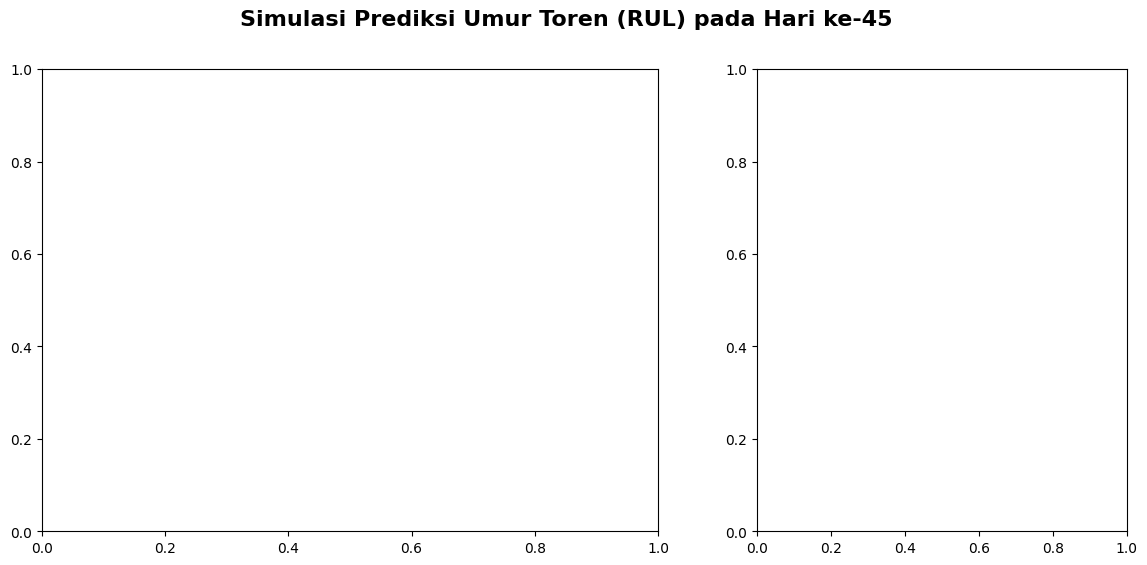

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 1.2]})
fig.suptitle(f'Simulasi Prediksi Umur Toren (RUL) pada Hari ke-{hari_sekarang}', fontsize=16, fontweight='bold')

In [ ]:
# --- PANEL KIRI: Grafik Sensor ---
batas_tampil = 60
ax1.plot(df['Hari'][:batas_tampil], df['Turbidity'][:batas_tampil], color='royalblue', linewidth=2, alpha=0.7, label='Historis Turbidity Asli')

hari_window = df['Hari'][idx_awal:idx_akhir]
turbidity_window = df['Turbidity'][idx_awal:idx_akhir]

ax1.axvspan(df['Hari'].iloc[idx_awal], df['Hari'].iloc[idx_akhir-1], color='orange', alpha=0.2, label='Memori GRU (5 Hari)')
ax1.plot(hari_window, turbidity_window, marker='o', color='darkorange', linewidth=2, markersize=7)

ax1.axvline(x=hari_sekarang, color='red', linestyle='--', alpha=0.6, label='Titik Waktu Saat Ini')

ax1.set_xlabel('Waktu (Hari ke-)', fontsize=12)
ax1.set_ylabel('Sensor Turbidity (NTU)', fontsize=12)
ax1.set_title('Polanya Dibaca oleh Model (Input X)', fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

In [ ]:
# --- PANEL KANAN: Hasil Prediksi ---
# Menempatkan XGBoost berdampingan dengan GRU agar mudah dibandingkan
kategori = ['RUL Asli', 'Prediksi XGBoost', 'Prediksi GRU']
nilai = [true_rul, pred_xgb, pred_gru]
warna = ['#2ca02c', '#ff7f0e', '#1f77b4'] 

bars = ax2.bar(kategori, nilai, color=warna, alpha=0.85, width=0.6)

for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f} Hari', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax2.set_ylabel('Sisa Hari (RUL)', fontsize=12)
ax2.set_title('Hasil Prediksi Sisa Waktu (Output y)', fontsize=13)
ax2.set_ylim(0, max(nilai) + 15) 
ax2.grid(axis='y', linestyle='--', alpha=0.5)

In [ ]:
plt.tight_layout()
plt.show()

In [10]:
# Bintang merah sebagai prediksi RUL di hari berikutnya
ax.plot(x_target, y_target, marker='*', color='red', markersize=15, label='Target Prediksi (Output y)')